In [1]:
import os
from collections import Counter

import nltk
import pandas as pd
import visual_graph
from nltk.corpus import stopwords

n_workers = min(11, os.cpu_count() - 1)

nltk.download('stopwords')
nltk.download('punkt_tab')
stop_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/calin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/calin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
email_df = pd.read_csv("dataset/emails/all_emails2.csv")
email_df.dropna(subset=["subject", "body", "label"], inplace=True)

email_df['text'] = email_df['subject'] + " [SUBJECT] " + email_df['body']

non_phsihing_emails = email_df[email_df['label'] % 2 == 0]

phishing_emails = email_df[email_df['label']% 2 == 1].head(non_phsihing_emails.shape[0])

new_email_df = pd.concat([email_df[email_df['label'] % 2 == 0], phishing_emails], ignore_index=True)

email_df = new_email_df

email_df

,sender,receiver,date,subject,body,label,urls,text
0,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,Re: svn commit: r619753 - in /spamassassin/tru...
1,qydlqcws-iacfym@issues.apache.org,xrh@spamassassin.apache.org,"Tue, 05 Aug 2008 15:31:03 -0800",[Bug 5780] URI processing turns uuencoded stri...,http://issues.apache.org/SpamAssassin/show_bug...,0,1,[Bug 5780] URI processing turns uuencoded stri...
2,Racing <uqyrmo@sailing.ie>,user5@gvc.ceas-challenge.cc,"Wed, 06 Aug 2008 00:31:14 +0100",RE: Trial IRC Certificate Application,"\nPlelim,\n\nJust to remind you that if a cert...",0,1,RE: Trial IRC Certificate Application [SUBJECT...
3,Aaron Kulkis <cmiqlkx91@hotpop.com>,opensuse <wkilxloc@opensuse.org>,"Tue, 05 Aug 2008 15:50:37 -0500","Re: [opensuse] Why can't I use ""shutdown now"" ...",Carlos E. R. wrote: > -----BEGIN PGP SIGNED ME...,0,1,"Re: [opensuse] Why can't I use ""shutdown now"" ..."
4,Aaron Kulkis <cmiqlkx91@hotpop.com>,opensuse <wkilxloc@opensuse.org>,"Tue, 05 Aug 2008 16:31:41 -0500",Re: Fwd: [opensuse] Re: openSUSE Boxed Editions,Steve Jacobs wrote: > ---------- Forwarded mes...,0,1,Re: Fwd: [opensuse] Re: openSUSE Boxed Edition...
...,...,...,...,...,...,...,...,...
41527,Glen Marino <dwwebsitedesigningm@websitedesign...,user8.3@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 23:15:05 -1200",Your own health and the health of those you l...,\n\n\n\n\nWe Pro cx vi qws de You With The B y...,1,0,Your own health and the health of those you l...
41528,Alonzo Buchanan <ConradgladiolusBrock@georgia....,btis@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 14:13:47 -0200",High Quality Rolex Replica Watches,\nAstonishing replica watches at Replica Class...,1,1,High Quality Rolex Replica Watches [SUBJECT] \...
41529,Darin Morton <TommiecontraventionLloyd@secretc...,"stewart.d.ferer@gvc.ceas-challenge.cc, thisisj...","Fri, 08 Aug 2008 08:14:36 +0300","Replica watches, pens, bags and more... Cheap ...",\nWe offer a free gift box with every VIP watc...,1,1,"Replica watches, pens, bags and more... Cheap ..."
41530,Frankie Poole <SantiagoracketeerBrady@experien...,"humanmenu@gvc.ceas-challenge.cc, kelly_f_eliso...","Fri, 08 Aug 2008 08:13:44 +0300",Get the Finest Rolex Watch Replica !,\n- Guaranteed triple-wrapped gold on all-gold...,1,1,Get the Finest Rolex Watch Replica ! [SUBJE...


In [3]:
import unicodedata
from bs4 import BeautifulSoup
import re
from nltk.tokenize import TweetTokenizer, word_tokenize

def strip_html(text):
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)
    text = re.sub(r"&[a-z]+;", " ", text)
    return text


def mask_entities(text):
    text = re.sub(r"http[s]?://\S+", " ___URL___ ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ___EMAIL___ ", text)
    text = re.sub(r"\d+(?:[\.,]\d+)*", " ___NUM___ ", text)
    return text


def normalize_text(text):
    text = text.lower()
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_punctuation(text):
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_and_remove_stopwords(text):
    tokens = [t for t in word_tokenize(text) if t not in stop_en]
    return tokens


def clean_text_pipeline(raw):
    text = strip_html(raw)
    text = mask_entities(text)
    text = normalize_text(text)
    text = remove_punctuation(text)
    tokens = tokenize_and_remove_stopwords(text)
    return tokens

In [4]:
from joblib import Parallel, delayed

tokens = Parallel(n_jobs=n_workers, backend="loky", verbose=2)(
    delayed(clean_text_pipeline)(txt) for txt in email_df["text"]
)
email_df["tokens"] = tokens

[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  19 tasks      | elapsed:    1.5s
[Parallel(n_jobs=11)]: Done 667 tasks      | elapsed:    1.8s
[Parallel(n_jobs=11)]: Done 22795 tasks      | elapsed:    5.0s
[Parallel(n_jobs=11)]: Done 41532 out of 41532 | elapsed:    5.9s finished


In [5]:
VOCAB_SIZE = 15_000
MIN_FREQ = 5
RESERVED = ["<pad>", "<unk>", "___url___", "___email___", "___num___"]

all_tokens = [tok for tokens in email_df['tokens'] for tok in tokens]
counter = Counter(all_tokens)
most_common = counter.most_common(25_000)
string_to_integer = {"<pad>": 0, "<unk>": 1}

for idx, (tok, _) in enumerate(most_common, start=2):
    string_to_integer[tok] = idx
integer_to_string = {idx: tok for tok, idx in string_to_integer.items()}

import json

with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(string_to_integer, f, ensure_ascii=False, indent=2)

In [6]:
import numpy as np
import fasttext

ft = fasttext.load_model("dataset/emails/cc.en.300.bin")
EMB_DIM = ft.get_dimension()

vocab_size = len(string_to_integer)
pad_idx = string_to_integer["<pad>"]
unk_idx = string_to_integer["<unk>"]

embedding_matrix = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)

for token, idx in string_to_integer.items():
    if idx in (pad_idx, unk_idx):
        continue
    try:
        embedding_matrix[idx] = ft.get_word_vector(token)
    except Exception:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMB_DIM,))

np.save("embedding_matrix.npy", embedding_matrix)

In [7]:
unk = string_to_integer["<unk>"]


def encode(tokens):
    return [string_to_integer.get(t, unk) for t in tokens]


email_df["encoded"] = email_df["tokens"].apply(encode)

In [8]:
from torch.utils.data import Dataset
import torch.nn.utils.rnn as rnn_utils


class PhishingDataset(Dataset):
    def __init__(self, encodings, labels, max_length=200):
        self.enc = encodings
        self.lab = labels
        self.max = max_length
        self.lengths = [min(len(seq), max_length) for seq in encodings]

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx_arg):
        seq = self.enc[idx_arg][: self.max]
        y = torch.tensor(self.lab[idx_arg], dtype=torch.float32).unsqueeze(0)
        return torch.tensor(seq, dtype=torch.long), self.lengths[idx_arg], y


def collate_fn(batch):
    seqs, lens, labels = zip(*batch)
    padded = rnn_utils.pad_sequence(seqs, batch_first=True,
                                    padding_value=string_to_integer["<pad>"])
    lens = torch.tensor(lens, dtype=torch.long).to(padded.device)
    labels = torch.cat(labels)
    return padded, lens, labels

In [9]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

X = email_df['encoded'].tolist()
y = email_df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

train_ds = PhishingDataset(X_train, y_train)
val_ds = PhishingDataset(X_val, y_val)
test_ds = PhishingDataset(X_test, y_test)

batch_size = 64
loader_kwargs = dict(
    batch_size=batch_size,
    collate_fn=collate_fn,
    num_workers=n_workers,
    pin_memory=True,
    persistent_workers=(n_workers > 0)
)

train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs)

In [10]:
import torchmetrics
import torch.nn as nn
import pytorch_lightning as pl


class LitPhishingLSTM(pl.LightningModule):
    def __init__(self, embedding_matrix, hidden_dim=64,
                 num_layers=1, dropout=0.35, pad_idx=0, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=["embedding_matrix"])

        weights = torch.tensor(embedding_matrix)
        self.embedding = nn.Embedding.from_pretrained(
            weights, freeze=False, padding_idx=pad_idx
        )
        self.emb_drop = nn.Dropout1d(0.2)

        self.lstm = nn.LSTM(
            input_size=weights.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

        self.criterion = nn.BCEWithLogitsLoss()

        self.train_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")

        self.val_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")
        self.val_precision = torchmetrics.Precision(threshold=0.5, task="binary")
        self.val_rec = torchmetrics.Recall(threshold=0.5, task="binary")
        self.val_f1 = torchmetrics.F1Score(threshold=0.5, task="binary")

        self.test_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")
        self.test_precision = torchmetrics.Precision(threshold=0.5, task="binary")
        self.test_recall = torchmetrics.Recall(threshold=0.5, task="binary")
        self.test_f1 = torchmetrics.F1Score(threshold=0.5, task="binary")

    def forward(self, x, lengths):
        emb = self.emb_drop(self.embedding(x).transpose(1, 2)).transpose(1, 2)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        pooled, _ = torch.max(out, 1)
        return self.fc(pooled).squeeze(1)

    def _common_step(self, batch):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss   = self.criterion(logits, y)
        probability  = torch.sigmoid(logits)
        return loss, probability, y


    def training_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.train_acc.update(probs, y)
        self.log("train_loss", loss,
                 prog_bar=True, on_step=True, on_epoch=False)
        return loss


    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc.compute(),
                 prog_bar=True, on_step=False, on_epoch=True)
        self.train_acc.reset()


    def validation_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.val_acc.update(probs, y)
        self.val_precision.update(probs, y)
        self.val_rec.update(probs, y)
        self.val_f1.update(probs, y)
        self.log("val_loss", loss, prog_bar=False, on_step=False, on_epoch=True)


    def on_validation_epoch_end(self):
        self.log_dict({
            "val_acc": self.val_acc.compute(),
            "val_precision": self.val_precision.compute(),
            "val_rec": self.val_rec.compute(),
            "val_f1": self.val_f1.compute(),
        }, prog_bar=True)
        self.val_acc.reset()
        self.val_precision.reset()
        self.val_rec.reset()
        self.val_f1.reset()


    def test_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.test_acc.update(probs, y)
        self.test_precision.update(probs, y)
        self.test_recall.update(probs, y)
        self.test_f1.update(probs, y)
        self.log("test_loss", loss, prog_bar=False)


    def on_test_epoch_end(self):
        self.log_dict({
            "test_acc": self.test_acc.compute(),
            "test_precision": self.test_precision.compute(),
            "test_rec": self.test_recall.compute(),
            "test_f1": self.test_f1.compute(),
        }, prog_bar=True)
        self.test_acc.reset()
        self.test_precision.reset()
        self.test_recall.reset()
        self.test_f1.reset()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                           factor=0.5, patience=2)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched,
                                                   "monitor": "val_loss"}}


In [11]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar
from pytorch_lightning import Trainer
import torch


model = LitPhishingLSTM(
    embedding_matrix = embedding_matrix,
    hidden_dim       = 128,
    num_layers       = 2,
    dropout          = 0.35,
    pad_idx          = string_to_integer["<pad>"],
    lr               = 1e-4
)

class NoValProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = super().init_validation_tqdm()
        bar.disable = True
        return bar
    def init_test_tqdm(self):
        bar = super().init_test_tqdm()
        bar.disable = True
        return bar

es   = EarlyStopping(monitor="val_loss", patience=3, mode="min")
ckpt = ModelCheckpoint(monitor="val_f1",
                       mode="max",
                       filename="best-phishing-lstm")

from pytorch_lightning.loggers import CSVLogger
csv_logger = CSVLogger("lightning_logs", name="phishing_run")

trainer = Trainer(
    max_epochs          = 10,
    accelerator         = "gpu",
    devices             = 1,
    deterministic       = False,
    callbacks           = [es, ckpt, NoValProgressBar()],
    log_every_n_steps   = 50,
    gradient_clip_val   = 1.0,
    logger=[csv_logger]
)

trainer.fit(model, train_loader, val_loader)

trainer.test(model, dataloaders=test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name           | Type              | Params | Mode 
--------------------------------------------------------------
0  | embedding      | Embedding         | 7.5 M  | train
1  | emb_drop       | Dropout1d         | 0      | train
2  | lstm           | LSTM              | 835 K  | train
3  | fc             | Linear            | 257    | train
4  | criterion      | BCEWithLogitsLoss | 0      | train
5  | train_acc      | BinaryAccuracy    | 0      | train
6  |

Epoch 9: 100%|██████████| 454/454 [00:20<00:00, 22.57it/s, v_num=3, train_loss=0.000339, val_acc=0.998, val_precision=0.997, val_rec=0.998, val_f1=0.998, train_acc=0.999]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 454/454 [00:20<00:00, 22.22it/s, v_num=3, train_loss=0.000339, val_acc=0.998, val_precision=0.997, val_rec=0.998, val_f1=0.998, train_acc=0.999]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9961476922035217
         test_f1            0.9961526393890381
        test_loss           0.0173632875084877
     test_precision         0.9948767423629761
        test_rec             0.997431755065918
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.0173632875084877,
  'test_acc': 0.9961476922035217,
  'test_precision': 0.9948767423629761,
  'test_rec': 0.997431755065918,
  'test_f1': 0.9961526393890381}]

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc


def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=True, cmap="Blues"):
    cm = confusion_matrix(
        y_true, y_pred, normalize="true" if normalize else None
    )
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap, vmin=0, vmax=1 if normalize else None)
    ax.set(title="Confusion Matrix",
           xlabel="Predicted label", ylabel="True label")

    if labels is None:
        labels = ["0", "1"]
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = f"{cm[i, j]:.2f}" if normalize else f"{cm[i, j]:d}"
            color = "white" if cm[i, j] > (0.5 if normalize else cm.max()/2) else "black"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

    return cm

def plot_roc_auc(y_true, y_scores, threshold=0.5):
    fpr, tpr, thresh = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4,4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    idx = np.argmin(np.abs(thresh - threshold))
    plt.scatter(fpr[idx], tpr[idx], marker="o", color="red",
                label=f"thr={threshold:.2f}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roc_auc





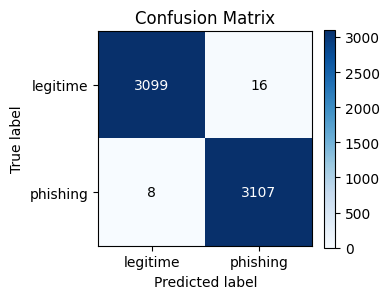

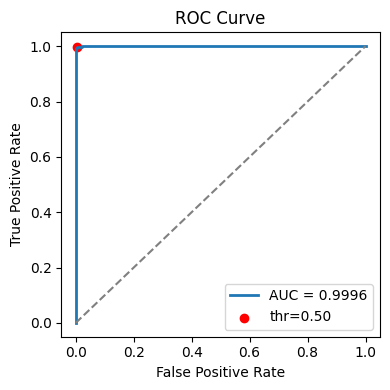

0.9995858078113204

In [13]:
y_true, y_pred, y_scores = [], [], []
model.eval()
with torch.no_grad():
    for xb, lengths, yb in test_loader:
        xb = xb.to(model.device)
        lengths = lengths.to(model.device)
        logits = model(xb, lengths).cpu()
        probs  = torch.sigmoid(logits)

        y_true.extend(yb.cpu().tolist())
        y_pred.extend((probs >= 0.5).long().tolist())
        y_scores.extend(probs.tolist())

cm = plot_confusion_matrix(y_true, y_pred, normalize=False, labels=['legitime', 'phishing'])
plot_roc_auc(y_true, y_scores)

In [14]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

def bootstrap_ci(y_true, y_scores, thr=0.5, n_boot=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metrics = {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []}

    y_true  = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    for _ in range(n_boot):
        idx   = rng.integers(0, len(y_true), len(y_true))
        yt, ys = y_true[idx], y_scores[idx]
        yp     = (ys >= thr).astype(int)

        metrics["acc"].append(accuracy_score(yt, yp))
        metrics["prec"].append(precision_score(yt, yp, zero_division=0))
        metrics["rec"].append(recall_score(yt, yp))
        metrics["f1"].append(f1_score(yt, yp))
        metrics["auc"].append(roc_auc_score(yt, ys))

    ci = {
        m: (np.percentile(vals, 100*alpha/2),
            np.percentile(vals, 100*(1-alpha/2)))
        for m, vals in metrics.items()
    }
    return ci

In [15]:
ci95 = bootstrap_ci(y_true, y_scores, thr=0.5)

for m, (lo, hi) in ci95.items():
    print(f"{m.upper():5s} 95% CI: {lo:.4f} – {hi:.4f}")

ACC   95% CI: 0.9945 – 0.9978
PREC  95% CI: 0.9922 – 0.9975
REC   95% CI: 0.9958 – 0.9990
F1    95% CI: 0.9945 – 0.9977
AUC   95% CI: 0.9990 – 0.9999


In [16]:
print(model)

LitPhishingLSTM(
  (embedding): Embedding(25002, 300, padding_idx=0)
  (emb_drop): Dropout1d(p=0.2, inplace=False)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (criterion): BCEWithLogitsLoss()
  (train_acc): BinaryAccuracy()
  (val_acc): BinaryAccuracy()
  (val_precision): BinaryPrecision()
  (val_rec): BinaryRecall()
  (val_f1): BinaryF1Score()
  (test_acc): BinaryAccuracy()
  (test_precision): BinaryPrecision()
  (test_recall): BinaryRecall()
  (test_f1): BinaryF1Score()
)


In [22]:
import torch
from time import perf_counter

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

# --- 1) pregătește secvența şi lungimea ei ------------------
tok_ids = torch.tensor(X_test[0]).to(device)      # [seq_len]
length  = torch.tensor([tok_ids.numel()]).to(device)  # [1]

tok_ids = tok_ids.unsqueeze(0)   # → [1, seq_len]  (batch=1)

# --- 2) cronometrează inferenţa ------------------------------
N, times = 100, []
with torch.inference_mode():
    for _ in range(N):
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = perf_counter()

        _ = model(tok_ids, length)    # ← PASĂM ŞI lengths

        if device == "cuda":
            torch.cuda.synchronize()
        times.append(perf_counter() - t0)

mean = sum(times)/N*1000
std  = torch.std(torch.tensor(times))*1000
print(f"Medie: {mean:.2f} ms  |  Dev. std: {std:.2f} ms")


Medie: 5.97 ms  |  Dev. std: 1.14 ms
